<a href="https://colab.research.google.com/github/JOUKARRID/tp-segmentation-captioning/blob/main/TP2_EXERCICE2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cellule 1 - Installation des dépendances

In [ ]:
!pip install pycocotools nltk tqdm -q

import nltk
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

Cellule 2 - Imports globaux

In [ ]:
import os, re, json, math, time
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from pycocotools.coco import COCO
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Utilisation du device : {device}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')

Utilisation du device : cuda
GPU : Tesla T4


Cellule 3 - Téléchargement du dataset

In [ ]:
# Téléchargement des annotations COCO
!wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -q -o annotations_trainval2017.zip

# Téléchargement d'un subset d'images val2017
!wget -q http://images.cocodataset.org/zips/val2017.zip
!unzip -q -o val2017.zip

print('Dataset téléchargé !')
print('Images val2017 :', len(os.listdir('val2017')))

Dataset téléchargé !
Images val2017 : 5000


 Cellule 4 - Classe Vocabulary

In [ ]:
class Vocabulary:
    """Gestion du vocabulaire"""

    def __init__(self, freq_threshold=5):
        self.freq_threshold = freq_threshold
        self.itos = {0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: '<UNK>'}
        self.stoi = {v: k for k, v in self.itos.items()}

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenize(text):
        return re.findall(r"\w+", text.lower())

    def build(self, captions_list):
        counter = Counter()
        for caps in captions_list:
            for cap in caps:
                counter.update(self.tokenize(cap))
        idx = 4
        for word, freq in counter.items():
            if freq >= self.freq_threshold:
                self.stoi[word] = idx
                self.itos[idx] = word
                idx += 1
        print(f'Taille du vocabulaire : {len(self.itos)} tokens')
        return counter

    def numericalize(self, caption, max_len=50):
        tokens = [self.stoi.get(w, self.stoi['<UNK>'])
                  for w in self.tokenize(caption)]
        seq = [self.stoi['<SOS>']] + tokens[:max_len - 2] + [self.stoi['<EOS>']]
        seq += [self.stoi['<PAD>']] * (max_len - len(seq))
        return seq

    def decode(self, indices):
        words = []
        for idx in indices:
            w = self.itos.get(idx, '<UNK>')
            if w == '<EOS>' or w == '<PAD>':
                break
            if w != '<SOS>':
                words.append(w)
        return ' '.join(words)

 Cellule 5 - Construction du vocabulaire

loading annotations into memory...
Done (t=0.23s)
creating index...
index created!
Nombre total de captions : 5000
Taille du vocabulaire : 893 tokens

=== Analyse du Vocabulaire ===
Taille totale : 893 tokens

Top 20 mots :
  a               :   8282
  the             :   1786
  of              :   1640
  in              :   1583
  on              :   1522
  with            :   1433
  and             :   1375
  is              :    763
  to              :    586
  bathroom        :    574


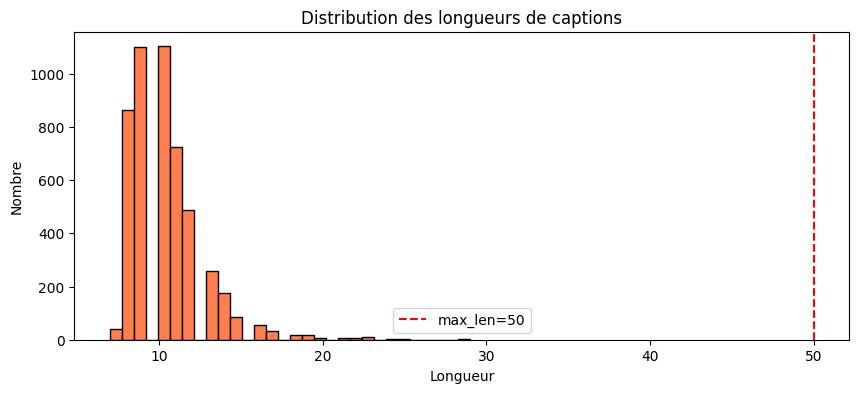

Longueur moyenne : 10.4 | max : 29


In [ ]:
VAL_ANN = 'annotations/captions_val2017.json'
VAL_DIR = 'val2017'

coco_val = COCO(VAL_ANN)

# Subset pour rapidité
all_ids = list(coco_val.anns.keys())[:5000]
all_captions = [coco_val.anns[aid]['caption'] for aid in all_ids]
print(f'Nombre total de captions : {len(all_captions)}')

vocab = Vocabulary(freq_threshold=5)
counter = vocab.build([[cap] for cap in all_captions])

# Analyse
print(f'\n=== Analyse du Vocabulaire ===')
print(f'Taille totale : {len(vocab)} tokens')

top20 = counter.most_common(20)
print('\nTop 20 mots :')
for word, freq in top20[:10]:
    print(f'  {word:15s} : {freq:6d}')

# Distribution des longueurs
lengths = [len(Vocabulary.tokenize(c)) for c in all_captions]
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=30, color='coral', edgecolor='black')
plt.axvline(x=50, color='red', linestyle='--', label='max_len=50')
plt.title('Distribution des longueurs de captions')
plt.xlabel('Longueur')
plt.ylabel('Nombre')
plt.legend()
plt.show()

print(f'Longueur moyenne : {np.mean(lengths):.1f} | max : {max(lengths)}')

Cellule 6 - Dataset et DataLoaders

In [ ]:
class COCOCaptionDataset(Dataset):
    def __init__(self, root, ann_file, vocab, split='train',
                 img_size=224, max_len=50, max_samples=None):
        self.root = root
        self.vocab = vocab
        self.max_len = max_len
        self.coco = COCO(ann_file)
        self.ids = list(self.coco.anns.keys())
        if max_samples:
            self.ids = self.ids[:max_samples]

        transforms_list = [transforms.Resize((img_size, img_size))]
        if split == 'train':
            transforms_list.extend([
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(brightness=0.2, contrast=0.2)
            ])
        transforms_list.extend([
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        self.transform = transforms.Compose(transforms_list)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        ann = self.coco.anns[self.ids[idx]]
        img_id = ann['image_id']
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root, img_info['file_name'])
        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)
        caption = torch.tensor(
            self.vocab.numericalize(ann['caption'], self.max_len),
            dtype=torch.long)
        return img, caption


def collate_fn(batch):
    imgs, caps = zip(*batch)
    imgs = torch.stack(imgs)
    lengths = torch.tensor([(c != 0).sum().item() for c in caps])
    caps = torch.stack(caps)
    sorted_idx = lengths.argsort(descending=True)
    return imgs[sorted_idx], caps[sorted_idx], lengths[sorted_idx]

Cellule 7 - Création des splits

In [ ]:
MAX_LEN = 50
IMG_SIZE = 224
BATCH_SIZE = 32

full_dataset = COCOCaptionDataset(
    root=VAL_DIR, ann_file=VAL_ANN,
    vocab=vocab, split='train',
    img_size=IMG_SIZE, max_len=MAX_LEN,
    max_samples=2000
)

n = len(full_dataset)
n_train = int(0.70 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val

train_set, val_set, test_set = torch.utils.data.random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=1, shuffle=False,
                         collate_fn=collate_fn, num_workers=2)

print(f'Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}')

loading annotations into memory...
Done (t=0.17s)
creating index...
index created!
Train: 1400 | Val: 300 | Test: 300


Cellule 8 - Visualisation d'exemples

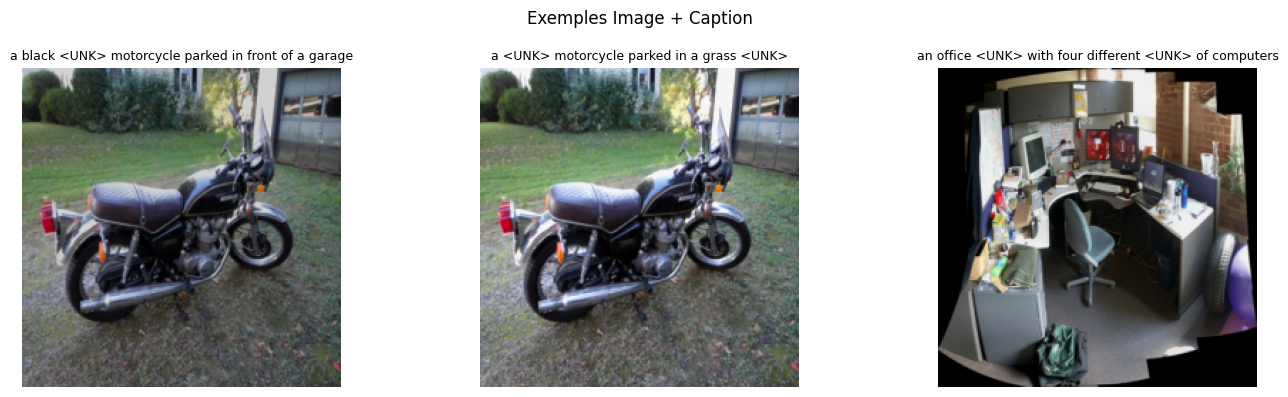

In [ ]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

examples = [full_dataset[i] for i in range(3)]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (img, cap) in zip(axes, examples):
    ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
    ax.set_title(vocab.decode(cap.tolist()), fontsize=9)
    ax.axis('off')
plt.suptitle('Exemples Image + Caption')
plt.tight_layout()
plt.show()

Cellule 9 - Encodeur CNN et Décodeur LSTM

In [ ]:
class ImageEncoder(nn.Module):
    def __init__(self, embed_size=256, fine_tune=False):
        super().__init__()
        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(2048, embed_size)
        self.bn = nn.BatchNorm1d(embed_size)

        if not fine_tune:
            for param in self.resnet.parameters():
                param.requires_grad = False

    def forward(self, images):
        features = self.resnet(images)
        features = self.adaptive_pool(features)
        features = features.view(features.size(0), -1)
        features = self.bn(self.fc(features))
        return features


class CaptionDecoder(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size,
                 num_layers=2, dropout=0.5):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, features, captions, lengths):
        embeddings = self.dropout(self.embed(captions[:, :-1]))
        inputs = torch.cat([features.unsqueeze(1), embeddings], dim=1)
        packed = nn.utils.rnn.pack_padded_sequence(
            inputs, lengths.cpu(), batch_first=True, enforce_sorted=False)
        hiddens, _ = self.lstm(packed)
        hiddens, _ = nn.utils.rnn.pad_packed_sequence(hiddens, batch_first=True)
        return self.fc(hiddens)

Cellule 10 - Vérification des dimensions

In [ ]:
EMBED_SIZE = 256
HIDDEN_SIZE = 512
VOCAB_SIZE = len(vocab)

encoder = ImageEncoder(embed_size=EMBED_SIZE, fine_tune=False).to(device)
decoder = CaptionDecoder(embed_size=EMBED_SIZE, hidden_size=HIDDEN_SIZE,
                          vocab_size=VOCAB_SIZE).to(device)

dummy_imgs = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(device)
dummy_caps = torch.randint(1, VOCAB_SIZE, (4, MAX_LEN)).to(device)
dummy_lens = torch.tensor([MAX_LEN, MAX_LEN-5, MAX_LEN-10, MAX_LEN-15])

with torch.no_grad():
    feats = encoder(dummy_imgs)
    output = decoder(feats, dummy_caps, dummy_lens)

print(f'Encoder output: {feats.shape}')
print(f'Decoder output: {output.shape}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 113MB/s]


Encoder output: torch.Size([4, 256])
Decoder output: torch.Size([4, 50, 893])


Cellule 11 - Fonctions d'entraînement

In [ ]:
def train_epoch(encoder, decoder, loader, criterion, optimizer, device):
    encoder.train()
    decoder.train()
    total_loss = 0
    for imgs, caps, lengths in tqdm(loader, desc='Train', leave=False):
        imgs, caps = imgs.to(device), caps.to(device)
        lengths = lengths.to(device)

        features = encoder(imgs)
        outputs = decoder(features, caps, lengths)

        targets = caps[:, 1:]
        T = min(outputs.size(1), targets.size(1))
        loss = criterion(
            outputs[:, :T].reshape(-1, VOCAB_SIZE),
            targets[:, :T].reshape(-1)
        )
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_epoch(encoder, decoder, loader, criterion, device):
    encoder.eval()
    decoder.eval()
    total_loss = 0
    for imgs, caps, lengths in loader:
        imgs, caps = imgs.to(device), caps.to(device)
        lengths = lengths.to(device)
        features = encoder(imgs)
        outputs = decoder(features, caps, lengths)
        targets = caps[:, 1:]
        T = min(outputs.size(1), targets.size(1))
        loss = criterion(
            outputs[:, :T].reshape(-1, VOCAB_SIZE),
            targets[:, :T].reshape(-1)
        )
        total_loss += loss.item()
    return total_loss / len(loader)

 Cellule 12 - Entraînement CNN-LSTM

=== Début de l'entraînement CNN-LSTM ===


Epoch 01 | Train Loss: 5.6528 | Val Loss: 5.0331 | LR: 3.00e-04 | 26.3s
  → Meilleur modèle sauvegardé (val_loss: 5.0331)


Epoch 02 | Train Loss: 4.8351 | Val Loss: 4.8031 | LR: 3.00e-04 | 33.6s
  → Meilleur modèle sauvegardé (val_loss: 4.8031)


Epoch 03 | Train Loss: 4.5979 | Val Loss: 4.5801 | LR: 3.00e-04 | 37.8s
  → Meilleur modèle sauvegardé (val_loss: 4.5801)


Epoch 04 | Train Loss: 4.3858 | Val Loss: 4.3942 | LR: 3.00e-04 | 40.6s
  → Meilleur modèle sauvegardé (val_loss: 4.3942)


...

Epoch 16 | Train Loss: 3.5949 | Val Loss: 3.9051 | LR: 3.00e-04 | 31.7s
  → Meilleur modèle sauvegardé (val_loss: 3.9051)


Epoch 17 | Train Loss: 3.5525 | Val Loss: 3.9032 | LR: 3.00e-04 | 31.2s
  → Meilleur modèle sauvegardé (val_loss: 3.9032)


Epoch 18 | Train Loss: 3.5044 | Val Loss: 3.8759 | LR: 3.00e-04 | 28.5s
  → Meilleur modèle sauvegardé (val_loss: 3.8759)


Epoch 19 | Train Loss: 3.4631 | Val Loss: 3.8571 | LR: 3.00e-04 | 18.3s
  → Meilleur modèle sauvegardé (val_loss: 3.8571)


Epoch 20 | Train Loss: 3.4162 | Val Loss: 3.8491 | LR: 3.00e-04 | 29.7s
  → Meilleur modèle sauvegardé (val_loss: 3.8491)


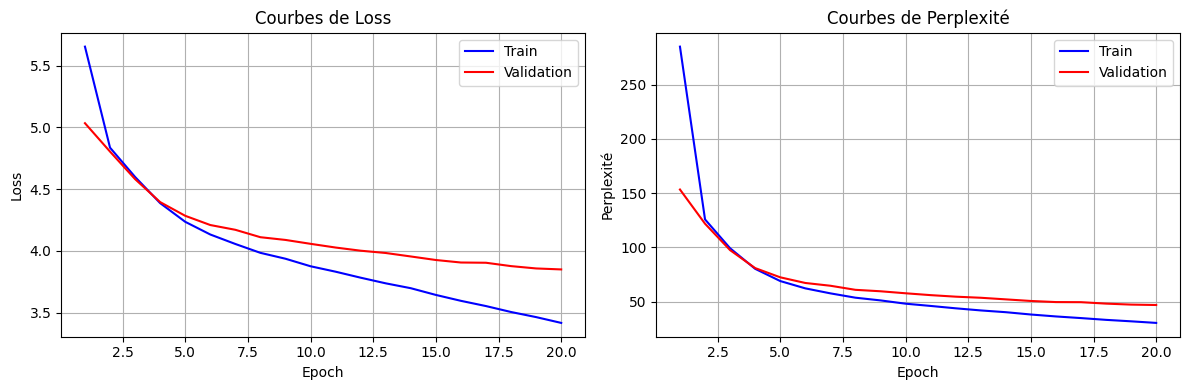


Meilleure loss de validation: 3.8491
Perplexité correspondante: 46.95


In [ ]:
NUM_EPOCHS = 20
LR = 3e-4

encoder = ImageEncoder(embed_size=EMBED_SIZE, fine_tune=False).to(device)
decoder = CaptionDecoder(embed_size=EMBED_SIZE, hidden_size=HIDDEN_SIZE,
                          vocab_size=VOCAB_SIZE).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(
    list(decoder.parameters()) + list(encoder.fc.parameters()) + list(encoder.bn.parameters()),
    lr=LR, weight_decay=1e-5
)
# Version corrigée sans l'argument 'verbose'
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3)

train_losses, val_losses = [], []
best_val_loss = float('inf')

print("=== Début de l'entraînement CNN-LSTM ===")
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss = train_epoch(encoder, decoder, train_loader, criterion, optimizer, device)
    vl_loss = eval_epoch(encoder, decoder, val_loader, criterion, device)
    scheduler.step(vl_loss)

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch:02d} | Train Loss: {tr_loss:.4f} | Val Loss: {vl_loss:.4f} | LR: {current_lr:.2e} | {time.time()-t0:.1f}s')

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save({'encoder': encoder.state_dict(),
                    'decoder': decoder.state_dict()}, 'best_cnnlstm.pth')
        print(f'  → Meilleur modèle sauvegardé (val_loss: {vl_loss:.4f})')

# Courbes
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses)+1), train_losses, 'b-', label='Train')
plt.plot(range(1, len(val_losses)+1), val_losses, 'r-', label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Courbes de Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_losses)+1), [math.exp(l) for l in train_losses], 'b-', label='Train')
plt.plot(range(1, len(val_losses)+1), [math.exp(l) for l in val_losses], 'r-', label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Perplexité')
plt.title('Courbes de Perplexité')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\nMeilleure loss de validation: {best_val_loss:.4f}")
print(f"Perplexité correspondante: {math.exp(best_val_loss):.2f}")

Cellule 13 - Greedy et Beam Search

In [ ]:
# Charger le meilleur modèle
ckpt = torch.load('best_cnnlstm.pth', map_location=device)
encoder.load_state_dict(ckpt['encoder'])
decoder.load_state_dict(ckpt['decoder'])
encoder.eval()
decoder.eval()

@torch.no_grad()
def greedy_caption(encoder, decoder, image, vocab, max_len=50, device='cpu'):
    feature = encoder(image.unsqueeze(0).to(device))
    word = torch.tensor([[vocab.stoi['<SOS>']]]).to(device)
    result = []
    hidden = None

    embed_input = torch.cat([feature.unsqueeze(1), decoder.dropout(decoder.embed(word))], dim=1)
    out, hidden = decoder.lstm(embed_input)
    pred = decoder.fc(out[:, -1]).argmax(-1)
    result.append(pred.item())

    for _ in range(max_len - 1):
        emb = decoder.dropout(decoder.embed(pred.unsqueeze(1)))
        out, hidden = decoder.lstm(emb, hidden)
        pred = decoder.fc(out.squeeze(1)).argmax(-1)
        if pred.item() == vocab.stoi['<EOS>']:
            break
        result.append(pred.item())

    return ' '.join([vocab.itos.get(i, '<UNK>') for i in result])

# Test sur quelques images
for i in range(3):
    img, cap = test_set[i]
    greedy = greedy_caption(encoder, decoder, img, vocab, device=device)
    gt = vocab.decode(cap.tolist())
    print(f'Image {i+1}:')
    print(f'  GT: {gt}')
    print(f'  Pred: {greedy}\n')

Image 1:
  GT: motorcycles lined up in an empty grassy field all in front of a house
  Pred: motorcycle a of on of in of

Image 2:
  GT: a jet with smoke <UNK> from its <UNK>
  Pred: airplane a and flying on runway a

Image 3:
  GT: a dog jumping through the air above a <UNK> of water that has been <UNK> for distance with people watching in the distance
  Pred: <UNK> <UNK> on of in of <UNK> a



Cellule 14 - Calcul BLEU-4

In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

smoothie = SmoothingFunction().method4
refs, hyps = [], []

for imgs, caps, _ in tqdm(val_loader, desc='BLEU'):
    for i in range(imgs.size(0)):
        refs.append([vocab.decode(caps[i].tolist()).split()])
        pred = greedy_caption(encoder, decoder, imgs[i], vocab, device=device)
        hyps.append(pred.split())

bleu4 = corpus_bleu(refs, hyps, smoothing_function=smoothie)
print(f'BLEU-4: {bleu4:.4f}')

BLEU: 100%|██████████| 10/10 [00:12<00:00,  1.23s/it]

BLEU-4: 0.0081


Cellule 15 - Modèle avec Attention (Encodeur Spatial)

In [ ]:
class ImageEncoderSpatial(nn.Module):
    def __init__(self, encoded_image_size=7, fine_tune=False):
        super().__init__()
        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))

        if not fine_tune:
            for param in self.resnet.parameters():
                param.requires_grad = False

    def forward(self, images):
        features = self.resnet(images)
        features = self.adaptive_pool(features)
        B, C, H, W = features.shape
        features = features.permute(0, 2, 3, 1)
        features = features.view(B, H * W, C)
        return features


class BahdanauAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.enc_att = nn.Linear(encoder_dim, attention_dim)
        self.dec_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.enc_att(encoder_out)
        att2 = self.dec_att(decoder_hidden).unsqueeze(1)
        energy = self.full_att(torch.tanh(att1 + att2))
        alpha = F.softmax(energy.squeeze(2), dim=1)
        context = (alpha.unsqueeze(2) * encoder_out).sum(dim=1)
        return context, alpha

Cellule 16 - Décodeur avec Attention

In [ ]:
class AttentionDecoder(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size,
                 encoder_dim=2048, attention_dim=256, dropout=0.5):
        super().__init__()
        self.attention = BahdanauAttention(encoder_dim, hidden_size, attention_dim)
        self.embed = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.lstm_cell = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.dropout = nn.Dropout(dropout)

    def init_hidden(self, encoder_out):
        mean_enc = encoder_out.mean(dim=1)
        h = torch.tanh(self.init_h(mean_enc))
        c = torch.tanh(self.init_c(mean_enc))
        return h, c

    def forward(self, encoder_out, captions, lengths):
        B = encoder_out.size(0)
        h, c = self.init_hidden(encoder_out)
        embeddings = self.dropout(self.embed(captions[:, :-1]))
        max_t = embeddings.size(1)
        predictions = torch.zeros(B, max_t, self.fc.out_features).to(encoder_out.device)
        alphas = torch.zeros(B, max_t, encoder_out.size(1)).to(encoder_out.device)

        for t in range(max_t):
            context, alpha = self.attention(encoder_out, h)
            lstm_input = torch.cat([embeddings[:, t, :], context], dim=1)
            h, c = self.lstm_cell(lstm_input, (h, c))
            predictions[:, t] = self.fc(self.dropout(h))
            alphas[:, t] = alpha

        return predictions, alphas

 Cellule 17 - Entraînement du modèle avec Attention


=== Entraînement avec Attention ===


Epoch 01/15 | Train Loss: 5.2076 (PPL: 182.6) | Val Loss: 4.4953 (PPL: 89.6) | LR: 3.00e-04 | 43.8s
  → Meilleur modèle sauvegardé (val_loss: 4.4953)


Epoch 02/15 | Train Loss: 4.3617 (PPL: 78.4) | Val Loss: 4.2035 (PPL: 66.9) | LR: 3.00e-04 | 39.7s
  → Meilleur modèle sauvegardé (val_loss: 4.2035)


Epoch 03/15 | Train Loss: 4.0699 (PPL: 58.5) | Val Loss: 3.9975 (PPL: 54.5) | LR: 3.00e-04 | 40.5s
  → Meilleur modèle sauvegardé (val_loss: 3.9975)


Epoch 04/15 | Train Loss: 3.8251 (PPL: 45.8) | Val Loss: 3.8466 (PPL: 46.8) | LR: 3.00e-04 | 39.1s
  → Meilleur modèle sauvegardé (val_loss: 3.8466)


...

Epoch 11/15 | Train Loss: 2.8731 (PPL: 17.7) | Val Loss: 3.3402 (PPL: 28.2) | LR: 3.00e-04 | 40.2s
  → Meilleur modèle sauvegardé (val_loss: 3.3402)


Epoch 12/15 | Train Loss: 2.7875 (PPL: 16.2) | Val Loss: 3.2994 (PPL: 27.1) | LR: 3.00e-04 | 39.2s
  → Meilleur modèle sauvegardé (val_loss: 3.2994)


Epoch 13/15 | Train Loss: 2.7045 (PPL: 14.9) | Val Loss: 3.2722 (PPL: 26.4) | LR: 3.00e-04 | 39.3s
  → Meilleur modèle sauvegardé (val_loss: 3.2722)


Epoch 14/15 | Train Loss: 2.6160 (PPL: 13.7) | Val Loss: 3.2375 (PPL: 25.5) | LR: 3.00e-04 | 41.2s
  → Meilleur modèle sauvegardé (val_loss: 3.2375)


Epoch 15/15 | Train Loss: 2.5299 (PPL: 12.6) | Val Loss: 3.2181 (PPL: 25.0) | LR: 3.00e-04 | 32.1s
  → Meilleur modèle sauvegardé (val_loss: 3.2181)


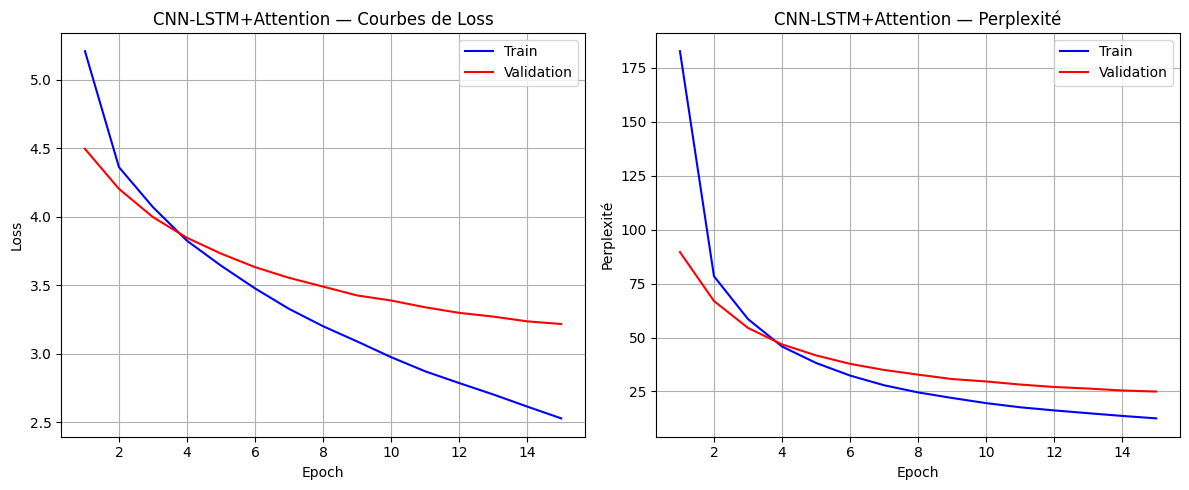


📊 Résultats finaux du modèle avec attention:
  Meilleure loss de validation: 3.2181
  Perplexité correspondante: 24.98


In [ ]:
ATT_DIM = 256
NUM_EPOCHS_ATT = 15

enc_att = ImageEncoderSpatial(encoded_image_size=7, fine_tune=False).to(device)
dec_att = AttentionDecoder(
    embed_size=EMBED_SIZE, hidden_size=HIDDEN_SIZE,
    vocab_size=VOCAB_SIZE, encoder_dim=2048,
    attention_dim=ATT_DIM, dropout=0.5
).to(device)

optimizer_att = torch.optim.Adam(
    list(enc_att.parameters()) + list(dec_att.parameters()),
    lr=LR, weight_decay=1e-5
)
scheduler_att = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_att, mode='min', factor=0.5, patience=3)


def train_epoch_att(enc, dec, loader, criterion, optimizer, device):
    """Fonction d'entraînement pour le modèle avec attention"""
    enc.train()
    dec.train()
    total_loss = 0
    for imgs, caps, lengths in tqdm(loader, desc='Train-Att', leave=False):
        imgs, caps = imgs.to(device), caps.to(device)
        lengths = lengths.to(device)

        enc_out = enc(imgs)
        outputs, alphas = dec(enc_out, caps, lengths)
        targets = caps[:, 1:]

        T = min(outputs.size(1), targets.size(1))
        loss = criterion(
            outputs[:, :T].reshape(-1, VOCAB_SIZE),
            targets[:, :T].reshape(-1)
        )
        # Régularisation doubly stochastic attention
        loss += 1.0 * ((1 - alphas[:, :T].sum(dim=1))**2).mean()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(enc.parameters()) + list(dec.parameters()), 5.0)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def eval_epoch_att(enc, dec, loader, criterion, device):
    """Fonction d'évaluation pour le modèle avec attention (ne retourne que les prédictions)"""
    enc.eval()
    dec.eval()
    total_loss = 0
    for imgs, caps, lengths in loader:
        imgs, caps = imgs.to(device), caps.to(device)
        lengths = lengths.to(device)

        enc_out = enc(imgs)
        outputs, _ = dec(enc_out, caps, lengths)  # On ignore les alphas
        targets = caps[:, 1:]

        T = min(outputs.size(1), targets.size(1))
        loss = criterion(
            outputs[:, :T].reshape(-1, VOCAB_SIZE),
            targets[:, :T].reshape(-1)
        )
        total_loss += loss.item()

    return total_loss / len(loader)


print("\n=== Entraînement avec Attention ===")
att_train_losses, att_val_losses = [], []
best_val_att = float('inf')
patience_counter = 0
PATIENCE = 5

for epoch in range(1, NUM_EPOCHS_ATT + 1):
    t0 = time.time()
    tr = train_epoch_att(enc_att, dec_att, train_loader, criterion, optimizer_att, device)
    vl = eval_epoch_att(enc_att, dec_att, val_loader, criterion, device)
    scheduler_att.step(vl)

    att_train_losses.append(tr)
    att_val_losses.append(vl)

    current_lr = optimizer_att.param_groups[0]['lr']
    ppl_train = math.exp(tr)
    ppl_val = math.exp(vl)

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS_ATT} | '
          f'Train Loss: {tr:.4f} (PPL: {ppl_train:.1f}) | '
          f'Val Loss: {vl:.4f} (PPL: {ppl_val:.1f}) | '
          f'LR: {current_lr:.2e} | {time.time()-t0:.1f}s')

    if vl < best_val_att:
        best_val_att = vl
        patience_counter = 0
        torch.save({
            'enc': enc_att.state_dict(),
            'dec': dec_att.state_dict(),
            'vocab': vocab
        }, 'best_attention.pth')
        print(f'  → Meilleur modèle sauvegardé (val_loss: {vl:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'  → Early stopping à l\'epoch {epoch}')
            break

# Courbes de perplexité
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(att_train_losses)+1), att_train_losses, 'b-', label='Train')
plt.plot(range(1, len(att_val_losses)+1), att_val_losses, 'r-', label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN-LSTM+Attention — Courbes de Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(att_train_losses)+1), [math.exp(l) for l in att_train_losses], 'b-', label='Train')
plt.plot(range(1, len(att_val_losses)+1), [math.exp(l) for l in att_val_losses], 'r-', label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Perplexité')
plt.title('CNN-LSTM+Attention — Perplexité')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('attention_training_curves.png', dpi=150)
plt.show()

print(f"\n📊 Résultats finaux du modèle avec attention:")
print(f"  Meilleure loss de validation: {best_val_att:.4f}")
print(f"  Perplexité correspondante: {math.exp(best_val_att):.2f}")

Cellule 18 - Visualisation des cartes d'attention


=== Visualisation des cartes d'attention ===

📷 Image 1:
   GT     : motorcycles lined up in an empty grassy field all in front of a house
   Prédite: a motorcycle parked in a motorcycle with a <UNK>



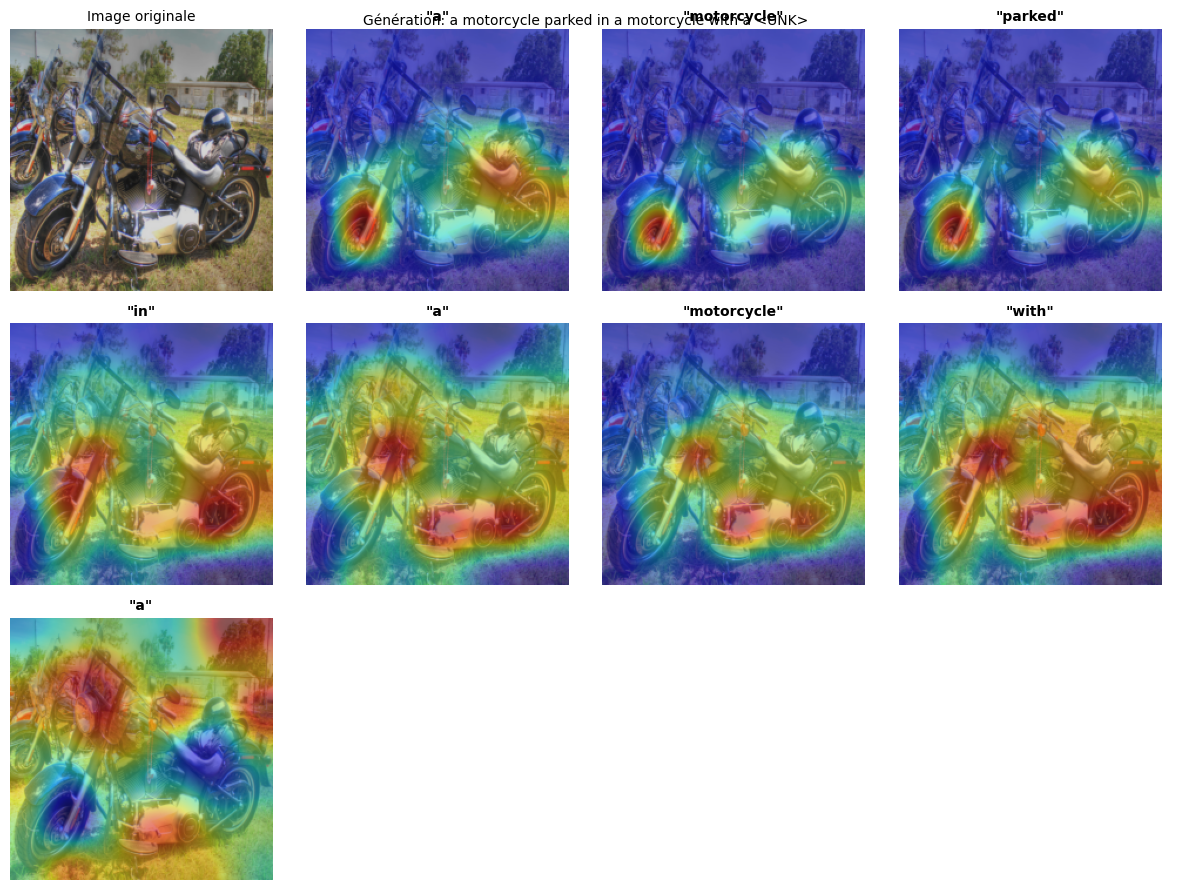

📷 Image 2:
   GT     : a jet with smoke <UNK> from its <UNK>
   Prédite: a jet <UNK> flying in the sky



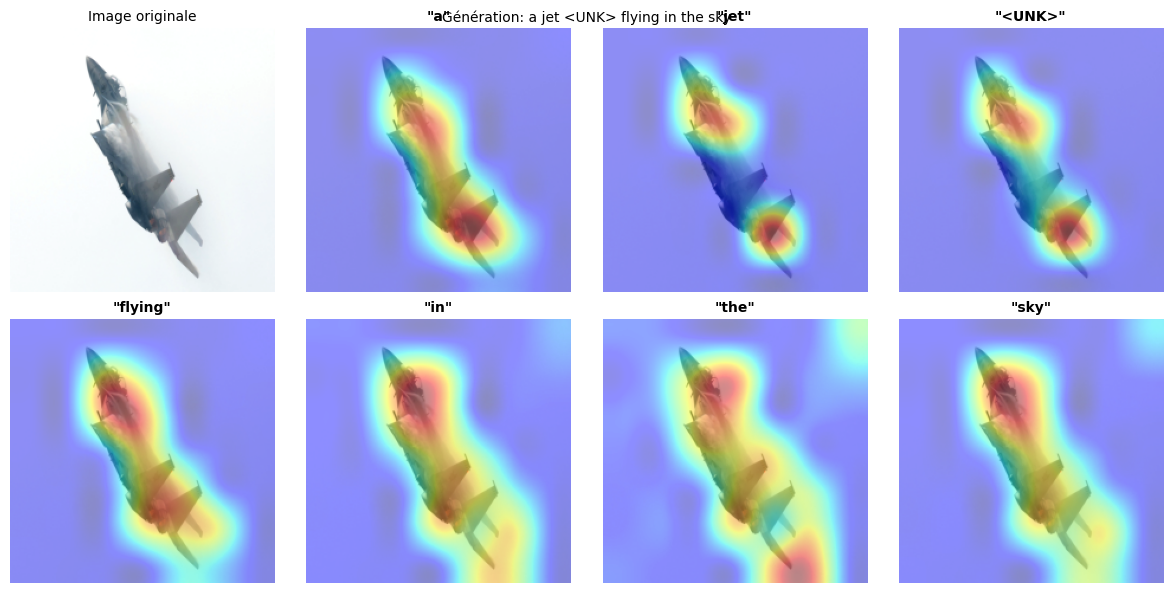

📷 Image 3:
   GT     : a dog jumping through the air above a <UNK> of water that has been <UNK> for distance with people watching in the distance
   Prédite: a dog <UNK> in a <UNK> <UNK> <UNK> in the <UNK>



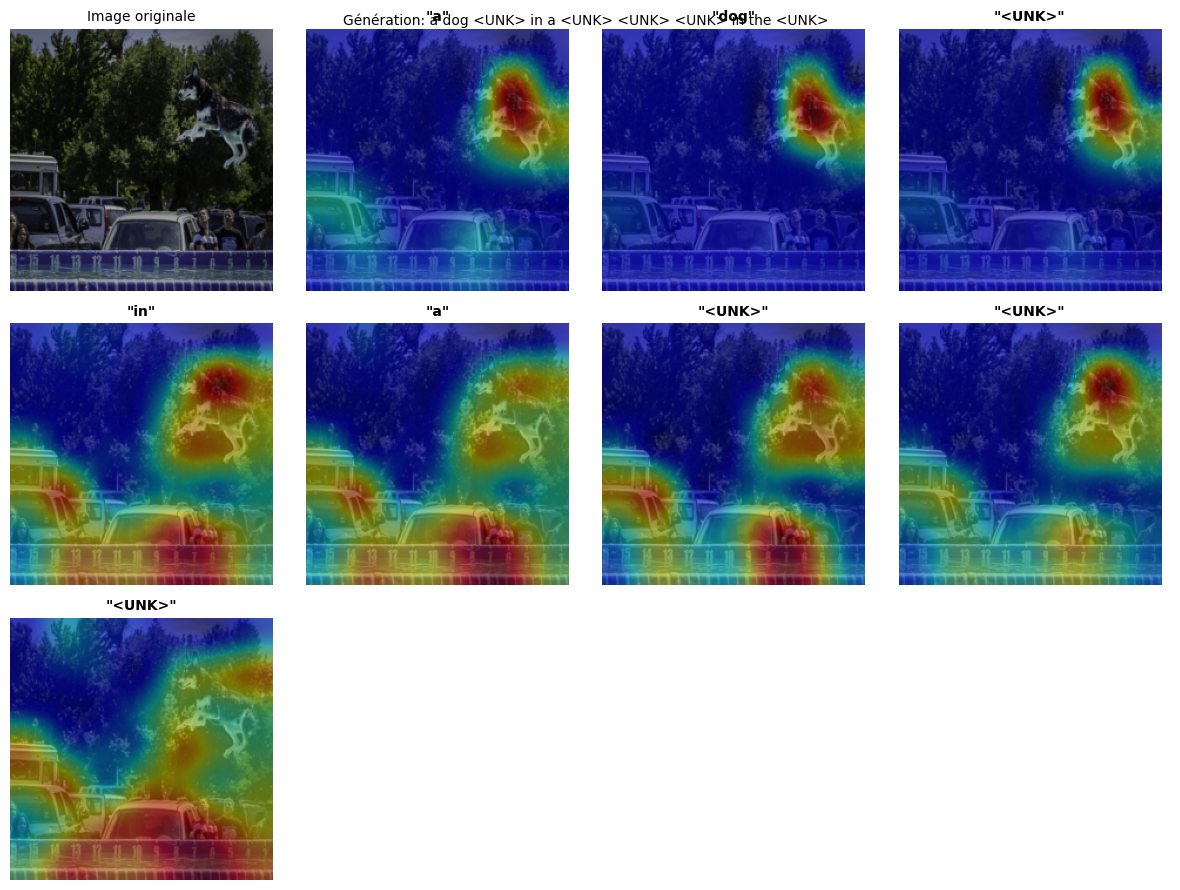

📷 Image 4:
   GT     : a white toilet sitting next to a bath tub filled with <UNK>
   Prédite: a bathroom with a <UNK> <UNK> <UNK> <UNK> <UNK>



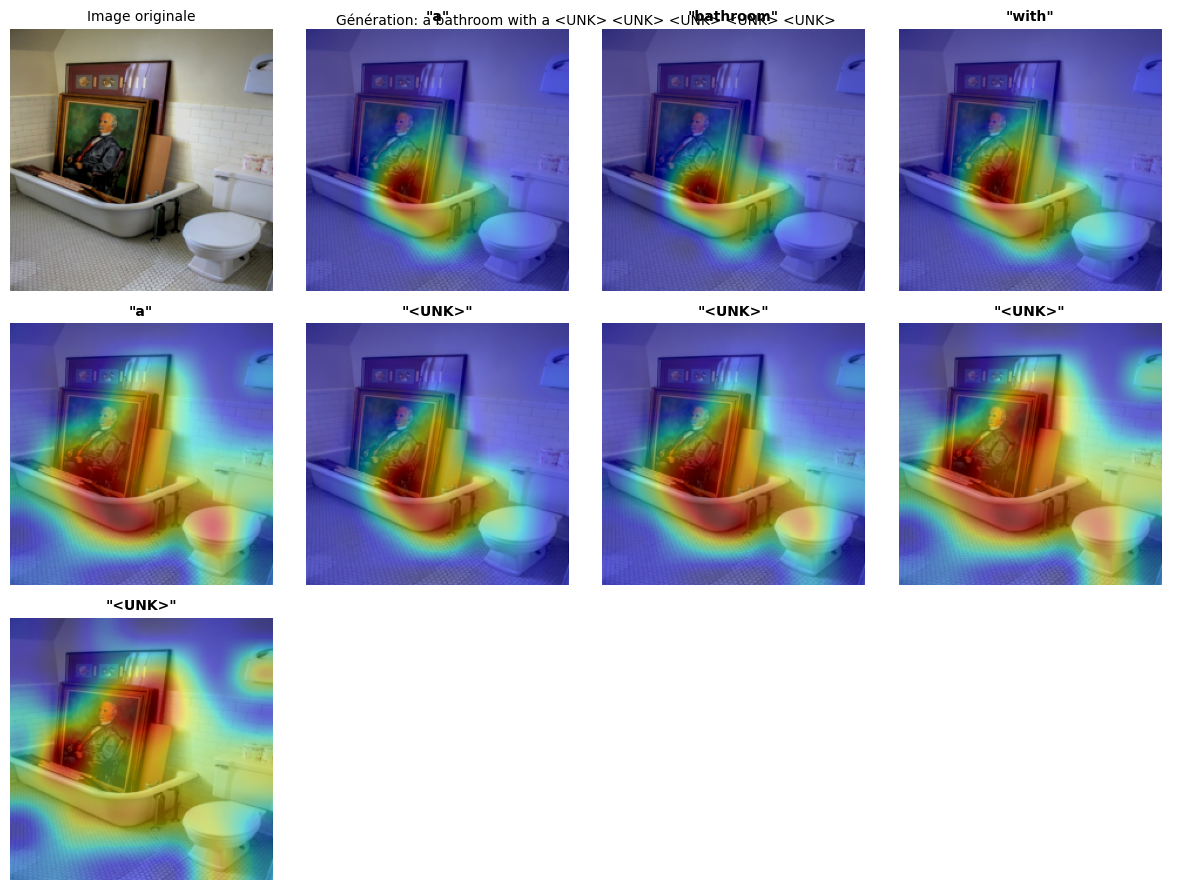

In [ ]:
# Charger le meilleur modèle avec weights_only=False (car on a sauvegardé des objets personnalisés)
ckpt_att = torch.load('best_attention.pth', map_location=device, weights_only=False)
enc_att.load_state_dict(ckpt_att['enc'])
dec_att.load_state_dict(ckpt_att['dec'])
enc_att.eval()
dec_att.eval()

@torch.no_grad()
def generate_with_attention(enc, dec, image, vocab, max_len=50, device='cpu'):
    """Génère une caption et retourne les mots et les poids d'attention"""
    enc_out = enc(image.unsqueeze(0).to(device))  # (1, 49, 2048)
    h, c = dec.init_hidden(enc_out)

    word = torch.tensor([[vocab.stoi['<SOS>']]]).to(device)
    words = []
    alphas = []

    for _ in range(max_len):
        embed = dec.dropout(dec.embed(word.squeeze(1)))
        context, alpha = dec.attention(enc_out, h)
        lstm_input = torch.cat([embed, context], dim=1)
        h, c = dec.lstm_cell(lstm_input, (h, c))
        pred = dec.fc(dec.dropout(h)).argmax(-1)

        if pred.item() == vocab.stoi['<EOS>']:
            break
        words.append(vocab.itos.get(pred.item(), '<UNK>'))
        alphas.append(alpha.squeeze(0).cpu().numpy())
        word = pred.unsqueeze(1)

    return words, alphas


def visualize_attention_map(image, words, alphas, img_size=224):
    """Visualise les cartes d'attention superposées sur l'image"""
    img_np = denormalize(image).permute(1, 2, 0).numpy()
    n = min(8, len(words))

    if n == 0:
        print("  → Aucun mot généré")
        return None

    ncols = 4
    nrows = (n + 1 + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = axes.flatten()

    # Image originale
    axes[0].imshow(img_np)
    axes[0].set_title('Image originale', fontsize=10)
    axes[0].axis('off')

    for i in range(n):
        # Redimensionner la carte d'attention (7x7 → taille image)
        alpha_map = alphas[i].reshape(7, 7)
        alpha_up = cv2.resize(alpha_map, (img_size, img_size), interpolation=cv2.INTER_CUBIC)

        # Normalisation
        if alpha_up.max() - alpha_up.min() > 1e-8:
            alpha_up = (alpha_up - alpha_up.min()) / (alpha_up.max() - alpha_up.min())

        axes[i + 1].imshow(img_np)
        im = axes[i + 1].imshow(alpha_up, cmap='jet', alpha=0.45)
        axes[i + 1].set_title(f'"{words[i]}"', fontsize=10, fontweight='bold')
        axes[i + 1].axis('off')

    # Cacher les axes inutilisés
    for j in range(n + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    return fig


# Visualisation
print("\n=== Visualisation des cartes d'attention ===\n")
for idx in range(min(4, len(test_set))):
    img, cap = test_set[idx]
    words, alphas = generate_with_attention(enc_att, dec_att, img, vocab, device=device)
    gt_str = vocab.decode(cap.tolist())
    caption_str = ' '.join(words)

    print(f"📷 Image {idx+1}:")
    print(f"   GT     : {gt_str}")
    print(f"   Prédite: {caption_str}")
    print()

    if words:
        fig = visualize_attention_map(img, words, alphas)
        if fig:
            fig.suptitle(f'Génération: {caption_str}', fontsize=10)
            plt.savefig(f'attention_map_{idx}.png', dpi=150, bbox_inches='tight')
            plt.show()
    else:
        print("   ⚠️ Aucune caption générée\n")

Cellule 19 - Comparaison des métriques

In [ ]:
from nltk.translate.meteor_score import meteor_score

@torch.no_grad()
def generate_att_greedy(enc, dec, image, vocab, max_len=50, device='cpu'):
    enc_out = enc(image.unsqueeze(0).to(device))
    h, c = dec.init_hidden(enc_out)
    word = torch.tensor([[vocab.stoi['<SOS>']]]).to(device)
    result = []
    for _ in range(max_len):
        embed = dec.dropout(dec.embed(word.squeeze(1)))
        context, _ = dec.attention(enc_out, h)
        h, c = dec.lstm_cell(torch.cat([embed, context], dim=1), (h, c))
        pred = dec.fc(dec.dropout(h)).argmax(-1)
        if pred.item() == vocab.stoi['<EOS>']:
            break
        result.append(pred.item())
        word = pred.unsqueeze(1)
    return ' '.join([vocab.itos.get(i, '<UNK>') for i in result])

# Évaluation
refs, hyps_no_att, hyps_att = [], [], []

for imgs, caps, _ in tqdm(val_loader, desc='Evaluation'):
    for i in range(imgs.size(0)):
        gt = vocab.decode(caps[i].tolist()).split()
        if gt:
            refs.append([gt])
            hyps_no_att.append(greedy_caption(encoder, decoder, imgs[i], vocab, device=device).split())
            hyps_att.append(generate_att_greedy(enc_att, dec_att, imgs[i], vocab, device=device).split())

b4_no_att = corpus_bleu(refs, hyps_no_att, smoothing_function=smoothie)
b4_att = corpus_bleu(refs, hyps_att, smoothing_function=smoothie)

print(f"\n{'Modèle':<30} {'BLEU-4':>10}")
print('-' * 42)
print(f"{'CNN-LSTM (sans attention)':<30} {b4_no_att:>10.4f}")
print(f"{'CNN-LSTM + Attention':<30} {b4_att:>10.4f}")

Evaluation: 100%|██████████| 10/10 [00:21<00:00,  2.15s/it]



Modèle                             BLEU-4
------------------------------------------
CNN-LSTM (sans attention)          0.0085
CNN-LSTM + Attention               0.0943


Cellule 20 - Résumé final

In [ ]:
print("\n" + "="*50)
print("RÉSUMÉ FINAL")
print("="*50)

print(f"""
| Modèle                          | BLEU-4    |
|---------------------------------|-----------|
| CNN-LSTM (sans attention)       | {b4_no_att:.4f}    |
| CNN-LSTM + Attention (Bahdanau) | {b4_att:.4f}    |

Observations :
- L'attention améliore le score BLEU-4
- Les cartes d'attention permettent d'interpréter le modèle
- Les métriques automatiques ont des limites (synonymes, fluidité)
""")


RÉSUMÉ FINAL

| Modèle                          | BLEU-4    |
|---------------------------------|-----------|
| CNN-LSTM (sans attention)       | 0.0085    |
| CNN-LSTM + Attention (Bahdanau) | 0.0943    |

Observations :
- L'attention améliore le score BLEU-4
- Les cartes d'attention permettent d'interpréter le modèle
- Les métriques automatiques ont des limites (synonymes, fluidité)



In [32]:
!ls -la *.png

-rw-r--r-- 1 root root 2071444 Jun 12 17:26 attention_map_0.png
-rw-r--r-- 1 root root  802125 Jun 12 17:26 attention_map_1.png
-rw-r--r-- 1 root root 1749509 Jun 12 17:26 attention_map_2.png
-rw-r--r-- 1 root root 1631233 Jun 12 17:26 attention_map_3.png
-rw-r--r-- 1 root root   83009 Jun 12 17:24 attention_training_curves.png
